# Hybrid ASR + LM Hallucination Detection Notebook

This notebook combines the two earlier detection ideas into one hybrid model:

1. **ASR-side uncertainty features**
   - features already available from ASR outputs such as `wer`, `avg_logprob`, `no_speech_prob`, and `compression_ratio`

2. **LM-side transcript uncertainty features**
   - features computed from `pred_text` using a text language model, such as perplexity and lexical instability measures

Main question:

> Does combining ASR-side uncertainty and LM-side uncertainty improve hallucination detection compared with using either one alone?

Why this notebook matters:
- your ASR-side notebook was stronger than the LM-side notebook
- the LM-side notebook still captured a different kind of signal
- combining both may improve robustness and detection recall

This notebook is written as a continuous report-friendly workflow, with explanation before each major step.


## Workflow Overview

This notebook performs the following steps:

1. Load and merge the human-labeled CSV files.
2. Clean the binary hallucination labels.
3. Build or load LM-derived transcript uncertainty features.
4. Combine ASR and LM features into a hybrid modeling table.
5. Run three groups of ablations:
   - ASR-only
   - LM-only
   - Hybrid combinations
6. Compare their ROC and DET behavior.
7. Inspect the best hybrid model in detail.
8. Save summary files for the final report.

The design goal is to let someone else read the notebook from top to bottom and understand both the method and the result.


In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn requests transformers torch tqdm


## 1. Configuration

This section controls:
- where the label CSVs come from
- which language model is used for transcript-side uncertainty
- how many ablations are run
- train/test split settings

Default behavior:
- download CSV files from your GitHub repository
- use `distilgpt2` for LM-side transcript uncertainty


In [2]:
from pathlib import Path

USE_GITHUB_REPO = True
GITHUB_OWNER = "GarimaTomar28"
GITHUB_REPO = "first-"
GITHUB_BRANCH = "main"

LOCAL_DATA_DIR = Path("hybrid_detector_data")
LOCAL_DATA_DIR.mkdir(exist_ok=True)

OUTPUT_DIR = Path("hybrid_detector_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

LM_MODEL_NAME = "distilgpt2"

TEST_SIZE = 0.30
RANDOM_STATE = 42
MIN_ROWS_FOR_MODELING = 30
MAX_TEXT_CHARS = 600

ASR_FEATURES = ["wer", "avg_logprob", "no_speech_prob", "compression_ratio"]
LM_FEATURES = [
    "lm_avg_neg_logprob",
    "lm_perplexity",
    "lm_surprisal_std",
    "repetition_ratio",
    "unique_token_ratio",
]

print("Using GitHub repo:", USE_GITHUB_REPO)
print("Input directory:", LOCAL_DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())
print("LM model:", LM_MODEL_NAME)
print("ASR features:", ASR_FEATURES)
print("LM features:", LM_FEATURES)


Using GitHub repo: True
Input directory: /content/hybrid_detector_data
Output directory: /content/hybrid_detector_outputs
LM model: distilgpt2
ASR features: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio']
LM features: ['lm_avg_neg_logprob', 'lm_perplexity', 'lm_surprisal_std', 'repetition_ratio', 'unique_token_ratio']


## 2. Download or discover labeled CSV files

This cell gathers the candidate CSV files that contain:
- predicted transcripts
- human labels
- ASR uncertainty features

The notebook later filters out files that do not contain usable labels.


In [3]:
import requests

downloaded_files = []

if USE_GITHUB_REPO:
    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents?ref={GITHUB_BRANCH}"
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    repo_items = resp.json()

    for item in repo_items:
        name = item["name"]
        if item["type"] == "file" and name.lower().endswith(".csv"):
            raw_url = item["download_url"]
            out_path = LOCAL_DATA_DIR / name
            file_resp = requests.get(raw_url, timeout=30)
            file_resp.raise_for_status()
            out_path.write_bytes(file_resp.content)
            downloaded_files.append(out_path)

    print("Downloaded CSV files:")
    for f in downloaded_files:
        print("-", f.name)
else:
    downloaded_files = sorted(LOCAL_DATA_DIR.glob("*.csv"))
    print("Using local CSV files:")
    for f in downloaded_files:
        print("-", f.name)


Downloaded CSV files:
- adversarial_labels (2).csv
- commonvoice_annotation_completed .csv
- librispeech_annotation_noisy.csv
- librispeech_labels.csv
- primock_medical_noisy_labels.csv


## 3. Load the candidate CSV files and keep the usable labeled ones

To be usable, a file must contain either:
- `hallucination_binary`, or
- `label_3class`

We also preserve the source filename so later analysis can show where examples came from.


In [4]:
import pandas as pd

candidate_frames = []
load_report = []

for csv_path in sorted(LOCAL_DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(csv_path)
        cols = set(df.columns)
        usable = ("hallucination_binary" in cols) or ("label_3class" in cols)
        load_report.append({
            "file": csv_path.name,
            "rows": len(df),
            "usable_for_labels": usable,
            "columns": list(df.columns),
        })
        if usable:
            df["source_file"] = csv_path.name
            candidate_frames.append(df)
    except Exception as exc:
        load_report.append({
            "file": csv_path.name,
            "rows": None,
            "usable_for_labels": False,
            "columns": [f"ERROR: {exc}"],
        })

load_report_df = pd.DataFrame(load_report)
display(load_report_df[["file", "rows", "usable_for_labels"]])

if not candidate_frames:
    raise ValueError("No usable labeled CSV files were found.")

raw_df = pd.concat(candidate_frames, ignore_index=True)
print("Merged candidate rows:", len(raw_df))
raw_df.head()


,file,rows,usable_for_labels
0,adversarial_labels (2).csv,100,True
1,commonvoice_annotation_completed .csv,73,True
2,librispeech_annotation_noisy.csv,292,True
3,librispeech_labels.csv,100,True
4,primock_medical_noisy_labels.csv,100,True


Merged candidate rows: 665


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,annotator_id,notes,source_file,meeting_id,speaker,noise_type,snr_db,audio_path
0,adversarial,adv_2961-960-0003,THEY WERE ABSORBED IN HIS THEOLOGY AND WERE UN...,They were absorbed in theology and were under ...,1.000000,-0.489062,0.199341,1.514085,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
1,adversarial,adv_8555-284447-0017,WHEN THIS HAD BEEN ACCOMPLISHED THE BOOLOOROO ...,And he was one of the most popular victims in ...,1.000000,-1.302190,0.182588,1.000000,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
2,adversarial,adv_2300-131720-0005,WHY IF WE ERECT A STATION AT THE FALLS IT IS A...,"Why, if we erect a station at the falls, it is...",1.000000,-0.353160,0.072554,1.112500,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
3,adversarial,adv_5142-36377-0022,I WISH YOU GOOD NIGHT SHE LAID HER BONY HANDS ...,I wish you would. Today we're going to hand th...,0.977273,-0.921636,0.340546,1.476510,Hallucination Error,hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN
4,adversarial,adv_8455-210777-0040,THEN SAID SIR FERDINANDO THERE IS NOTHING FOR ...,"Then, says Sir Fernando, there is nothing for ...",1.000000,-0.369825,0.079251,1.050000,Non-Hallucination Error,no_hallucination,member_4,NaN,adversarial_labels (2).csv,NaN,NaN,NaN,NaN,NaN


## 4. Clean the human labels and build the binary hallucination target

The binary target uses the same rules as the earlier notebooks:

- `Hallucination Error` -> `hallucination`
- `Non-Hallucination Error` -> `no_hallucination`
- `No Error` -> `no_hallucination`

This keeps the hybrid notebook directly comparable to the earlier results.


In [5]:
import numpy as np

df = raw_df.copy()

if "label_3class" not in df.columns:
    df["label_3class"] = np.nan

if "hallucination_binary" not in df.columns:
    df["hallucination_binary"] = np.nan

df["label_3class"] = df["label_3class"].astype(str).str.strip()
df["hallucination_binary"] = df["hallucination_binary"].astype(str).str.strip().str.lower()

label_map = {
    "Hallucination Error": "hallucination",
    "Non-Hallucination Error": "no_hallucination",
    "No Error": "no_hallucination",
}

missing_binary_mask = (
    ~df["label_3class"].isin(["nan", "None", ""])
    & ~df["hallucination_binary"].isin(["hallucination", "no_hallucination"])
)
df.loc[missing_binary_mask, "hallucination_binary"] = df.loc[missing_binary_mask, "label_3class"].map(label_map)

valid_df = df[df["hallucination_binary"].isin(["hallucination", "no_hallucination"])].copy()
valid_df["y"] = (valid_df["hallucination_binary"] == "hallucination").astype(int)

if valid_df.empty:
    raise ValueError("No valid rows remained after label cleaning.")

print("Usable rows after cleaning:", len(valid_df))
print()
print(valid_df["hallucination_binary"].value_counts())


Usable rows after cleaning: 665

hallucination_binary
no_hallucination    469
hallucination       196
Name: count, dtype: int64


## 5. Keep rows with usable predicted text

The LM side of the hybrid model depends on `pred_text`, so we:
- normalize transcript whitespace
- drop empty transcripts
- truncate overly long strings for more stable Colab runtime

This does not change the labels. It only makes feature extraction smoother.


In [6]:
analysis_df = valid_df.copy()

if "pred_text" not in analysis_df.columns:
    raise ValueError("The merged data does not contain a 'pred_text' column.")

analysis_df["pred_text"] = analysis_df["pred_text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
analysis_df["pred_text"] = analysis_df["pred_text"].str.slice(0, MAX_TEXT_CHARS)

analysis_df = analysis_df[analysis_df["pred_text"].str.len() > 0].copy()

if len(analysis_df) < MIN_ROWS_FOR_MODELING:
    raise ValueError("Too few rows with usable pred_text remained for modeling.")

print("Rows with usable pred_text:", len(analysis_df))
analysis_df[["hallucination_binary", "pred_text"]].head()


Rows with usable pred_text: 665


,hallucination_binary,pred_text
0,hallucination,They were absorbed in theology and were under ...
1,hallucination,And he was one of the most popular victims in ...
2,no_hallucination,"Why, if we erect a station at the falls, it is..."
3,hallucination,I wish you would. Today we're going to hand th...
4,no_hallucination,"Then, says Sir Fernando, there is nothing for ..."


## 6. Summarize the merged dataset

Before feature extraction, it helps to see:
- the class balance
- dataset contributions
- source-file contributions

This provides context for interpreting all later metrics.


In [7]:
display(
    analysis_df["hallucination_binary"]
    .value_counts(dropna=False)
    .rename_axis("class")
    .reset_index(name="count")
)

if "dataset" in analysis_df.columns:
    print("Counts by dataset and binary label:")
    display(pd.crosstab(analysis_df["dataset"], analysis_df["hallucination_binary"]))

print("Counts by source file and binary label:")
display(pd.crosstab(analysis_df["source_file"], analysis_df["hallucination_binary"]))

print("Counts by 3-class label:")
display(
    analysis_df["label_3class"]
    .value_counts(dropna=False)
    .rename_axis("label_3class")
    .reset_index(name="count")
)


,class,count
0,no_hallucination,469
1,hallucination,196


Counts by dataset and binary label:


hallucination_binary,hallucination,no_hallucination
dataset,,
adversarial,81,19
commonvoice,17,56
librispeech,0,100
librispeech_fallback,39,253
primock_medical_noisy,59,41


Counts by source file and binary label:


hallucination_binary,hallucination,no_hallucination
source_file,,
adversarial_labels (2).csv,81,19
commonvoice_annotation_completed .csv,17,56
librispeech_annotation_noisy.csv,39,253
librispeech_labels.csv,0,100
primock_medical_noisy_labels.csv,59,41


Counts by 3-class label:


,label_3class,count
0,Non-Hallucination Error,374
1,Hallucination Error,196
2,No Error,95


## 7. Load the language model for transcript-side uncertainty

The hybrid model keeps the earlier LM-side idea:
- use a text language model to judge how expected or unexpected the transcript looks

We use `distilgpt2` because:
- it is lightweight enough for Colab
- it provides usable next-token log-probability signals
- it is a practical baseline for transcript-only uncertainty


In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(LM_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(LM_MODEL_NAME).to(device)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded tokenizer and model:", LM_MODEL_NAME)


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded tokenizer and model: distilgpt2


## 8. Define LM-side uncertainty features

For each transcript, we compute:

1. `lm_avg_neg_logprob`
2. `lm_perplexity`
3. `lm_surprisal_std`
4. `repetition_ratio`
5. `unique_token_ratio`

Together these capture:
- how surprising the transcript looks
- how unstable token-level confidence is
- whether the transcript looks repetitive or structurally odd


In [9]:
import math

def compute_lm_features(text, max_length=256):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    if input_ids.shape[1] < 2:
        return {
            "lm_avg_neg_logprob": np.nan,
            "lm_perplexity": np.nan,
            "lm_surprisal_std": np.nan,
            "repetition_ratio": np.nan,
            "unique_token_ratio": np.nan,
            "token_count": int(input_ids.shape[1]),
        }

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits[:, :-1, :]
        target_ids = input_ids[:, 1:]

        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = log_probs.gather(dim=-1, index=target_ids.unsqueeze(-1)).squeeze(-1)
        token_neg_log_probs = -token_log_probs.squeeze(0).detach().cpu().numpy()

    avg_neg_logprob = float(np.mean(token_neg_log_probs))
    perplexity = float(math.exp(avg_neg_logprob)) if avg_neg_logprob < 20 else float("inf")
    surprisal_std = float(np.std(token_neg_log_probs))

    token_ids = input_ids.squeeze(0).detach().cpu().tolist()
    token_strs = tokenizer.convert_ids_to_tokens(token_ids)
    clean_tokens = [t for t in token_strs if t not in [tokenizer.bos_token, tokenizer.eos_token, tokenizer.pad_token]]

    if len(clean_tokens) <= 1:
        repetition_ratio = 0.0
        unique_token_ratio = 1.0 if clean_tokens else 0.0
    else:
        repeated_pairs = sum(1 for i in range(1, len(clean_tokens)) if clean_tokens[i] == clean_tokens[i - 1])
        repetition_ratio = repeated_pairs / max(1, len(clean_tokens) - 1)
        unique_token_ratio = len(set(clean_tokens)) / len(clean_tokens)

    return {
        "lm_avg_neg_logprob": avg_neg_logprob,
        "lm_perplexity": perplexity,
        "lm_surprisal_std": surprisal_std,
        "repetition_ratio": repetition_ratio,
        "unique_token_ratio": unique_token_ratio,
        "token_count": len(clean_tokens),
    }


## 9. Compute or load LM features

This is usually the slowest step in the notebook, so we support both:
- computing LM features from scratch
- reusing a previously saved enriched CSV if it already exists

That makes repeated experiments much easier.


In [10]:
from tqdm.auto import tqdm

feature_csv_path = OUTPUT_DIR / "hybrid_enriched_hallucination_data.csv"

if feature_csv_path.exists():
    print("Loading previously saved enriched feature table.")
    feature_df = pd.read_csv(feature_csv_path)
else:
    tqdm.pandas()
    lm_feature_dicts = []
    for text in tqdm(analysis_df["pred_text"].tolist(), desc="Computing LM features"):
        lm_feature_dicts.append(compute_lm_features(text))

    lm_features_df = pd.DataFrame(lm_feature_dicts)
    feature_df = pd.concat([analysis_df.reset_index(drop=True), lm_features_df.reset_index(drop=True)], axis=1)
    feature_df.to_csv(feature_csv_path, index=False)
    print("Saved enriched feature table to:", feature_csv_path.resolve())

feature_df.head()


Computing LM features:   0%|          | 0/665 [00:00<?, ?it/s]

Saved enriched feature table to: /content/hybrid_detector_outputs/hybrid_enriched_hallucination_data.csv


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,...,noise_type,snr_db,audio_path,y,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,token_count
0,adversarial,adv_2961-960-0003,THEY WERE ABSORBED IN HIS THEOLOGY AND WERE UN...,They were absorbed in theology and were under ...,1.000000,-0.489062,0.199341,1.514085,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.790422,120.352142,3.258551,0.0,0.780488,41
1,adversarial,adv_8555-284447-0017,WHEN THIS HAD BEEN ACCOMPLISHED THE BOOLOOROO ...,And he was one of the most popular victims in ...,1.000000,-1.302190,0.182588,1.000000,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.431953,84.095491,3.289205,0.0,0.933333,15
2,adversarial,adv_2300-131720-0005,WHY IF WE ERECT A STATION AT THE FALLS IT IS A...,"Why, if we erect a station at the falls, it is...",1.000000,-0.353160,0.072554,1.112500,Non-Hallucination Error,no_hallucination,...,NaN,NaN,NaN,0,4.067951,58.437086,3.235352,0.0,0.791667,24
3,adversarial,adv_5142-36377-0022,I WISH YOU GOOD NIGHT SHE LAID HER BONY HANDS ...,I wish you would. Today we're going to hand th...,0.977273,-0.921636,0.340546,1.476510,Hallucination Error,hallucination,...,NaN,NaN,NaN,1,4.695941,109.501798,3.227684,0.0,0.745455,55
4,adversarial,adv_8455-210777-0040,THEN SAID SIR FERDINANDO THERE IS NOTHING FOR ...,"Then, says Sir Fernando, there is nothing for ...",1.000000,-0.369825,0.079251,1.050000,Non-Hallucination Error,no_hallucination,...,NaN,NaN,NaN,0,4.446589,85.335327,2.244958,0.0,0.950000,20


## 10. Inspect feature availability

The hybrid model only works well if:
- ASR-side features are present
- LM-side features were computed successfully

This checkpoint helps verify that feature coverage is good before training.


In [11]:
feature_cols = ASR_FEATURES + LM_FEATURES

availability_df = pd.DataFrame({
    "feature": feature_cols,
    "missing_count": [feature_df[c].isna().sum() if c in feature_df.columns else len(feature_df) for c in feature_cols],
})

display(availability_df)


,feature,missing_count
0,wer,0
1,avg_logprob,0
2,no_speech_prob,0
3,compression_ratio,0
4,lm_avg_neg_logprob,0
5,lm_perplexity,0
6,lm_surprisal_std,0
7,repetition_ratio,0
8,unique_token_ratio,0


## 11. Build the final modeling table

This stage keeps only rows that have:
- valid labels
- all required feature values

From here onward, all ablations use the same modeling pool so their comparison stays fair.


In [12]:
present_features = [c for c in feature_cols if c in feature_df.columns]
model_cols = present_features + ["y"]
model_df = feature_df[model_cols].dropna().copy()

if len(model_df) < MIN_ROWS_FOR_MODELING:
    raise ValueError("Too few rows remain after dropping missing feature values.")

if model_df["y"].nunique() < 2:
    raise ValueError("Modeling requires both hallucination and no_hallucination classes.")

print("Rows used for modeling:", len(model_df))
print("Class counts used for modeling:")
print(model_df["y"].value_counts())
print("Features used for potential modeling:", present_features)


Rows used for modeling: 665
Class counts used for modeling:
y
0    469
1    196
Name: count, dtype: int64
Features used for potential modeling: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio', 'lm_avg_neg_logprob', 'lm_perplexity', 'lm_surprisal_std', 'repetition_ratio', 'unique_token_ratio']


## 12. Define the ablation families

We do not want just one hybrid result.
We want a structured comparison between:

1. **ASR-only ablations**
2. **LM-only ablations**
3. **Hybrid ablations**

This lets you answer:
- whether the LM features help at all
- whether ASR-only remains best
- whether the hybrid combination improves on both

To keep the notebook practical, we include:
- all single-feature and pairwise subsets for each family
- all full-family baselines
- a targeted set of larger hybrid combinations


In [13]:
from itertools import combinations

present_asr = [f for f in ASR_FEATURES if f in present_features]
present_lm = [f for f in LM_FEATURES if f in present_features]

ablation_specs = []

def add_spec(group, features):
    name = " + ".join(features)
    ablation_specs.append({
        "group": group,
        "features": features,
        "ablation_name": name,
    })

# ASR-only: singles, pairs, full set
for r in [1, 2]:
    for combo in combinations(present_asr, r):
        add_spec("ASR_only", list(combo))
if len(present_asr) >= 3:
    add_spec("ASR_only", present_asr)

# LM-only: singles, pairs, full set
for r in [1, 2]:
    for combo in combinations(present_lm, r):
        add_spec("LM_only", list(combo))
if len(present_lm) >= 3:
    add_spec("LM_only", present_lm)

# Hybrid: one ASR + one LM
for a in present_asr:
    for l in present_lm:
        add_spec("Hybrid", [a, l])

# Hybrid: two ASR + one LM
for a_combo in combinations(present_asr, min(2, len(present_asr))):
    for l in present_lm:
        add_spec("Hybrid", list(a_combo) + [l])

# Hybrid: one ASR + two LM
for l_combo in combinations(present_lm, min(2, len(present_lm))):
    for a in present_asr:
        add_spec("Hybrid", [a] + list(l_combo))

# Hybrid: full ASR + each LM
if len(present_asr) >= 2:
    for l in present_lm:
        add_spec("Hybrid", present_asr + [l])

# Hybrid: strongest broad baseline
add_spec("Hybrid", present_asr + present_lm)

# De-duplicate while preserving order
seen = set()
deduped_specs = []
for spec in ablation_specs:
    key = tuple(spec["features"])
    if key not in seen:
        seen.add(key)
        deduped_specs.append(spec)

ablation_specs = deduped_specs

print("Present ASR features:", present_asr)
print("Present LM features:", present_lm)
print("Total ablations to run:", len(ablation_specs))
pd.DataFrame(ablation_specs).head(20)


Present ASR features: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio']
Present LM features: ['lm_avg_neg_logprob', 'lm_perplexity', 'lm_surprisal_std', 'repetition_ratio', 'unique_token_ratio']
Total ablations to run: 123


,group,features,ablation_name
0,ASR_only,[wer],wer
1,ASR_only,[avg_logprob],avg_logprob
2,ASR_only,[no_speech_prob],no_speech_prob
3,ASR_only,[compression_ratio],compression_ratio
4,ASR_only,"[wer, avg_logprob]",wer + avg_logprob
5,ASR_only,"[wer, no_speech_prob]",wer + no_speech_prob
6,ASR_only,"[wer, compression_ratio]",wer + compression_ratio
7,ASR_only,"[avg_logprob, no_speech_prob]",avg_logprob + no_speech_prob
8,ASR_only,"[avg_logprob, compression_ratio]",avg_logprob + compression_ratio
9,ASR_only,"[no_speech_prob, compression_ratio]",no_speech_prob + compression_ratio


## 13. Train and evaluate all ablations

All ablations use:
- the same stratified train-test split
- the same logistic regression baseline
- the same evaluation metrics

Metrics reported:
- Accuracy
- Precision
- Recall
- F1
- ROC AUC
- Average Precision
- DET best threshold, FPR, FNR, and FPR+FNR

The DET-based ranking is especially useful for hallucination detection because it reflects the operational tradeoff between false alarms and missed hallucinations.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    det_curve,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

results = []
stored_runs = {}

for spec in ablation_specs:
    features = spec["features"]
    group = spec["group"]
    name = spec["ablation_name"]

    X = model_df[features]
    y = model_df["y"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    fpr_det, fnr_det, det_thresholds = det_curve(y_test, y_score)
    det_best_idx = int(np.argmin(fpr_det + fnr_det))

    row = {
        "group": group,
        "ablation_name": name,
        "features": "|".join(features),
        "n_features": len(features),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "avg_precision": average_precision_score(y_test, y_score),
        "det_best_threshold": float(det_thresholds[det_best_idx]),
        "det_best_fpr": float(fpr_det[det_best_idx]),
        "det_best_fnr": float(fnr_det[det_best_idx]),
        "det_fpr_plus_fnr": float(fpr_det[det_best_idx] + fnr_det[det_best_idx]),
    }
    results.append(row)

    stored_runs[name] = {
        "group": group,
        "features": features,
        "clf": clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_score": y_score,
        "fpr": fpr,
        "tpr": tpr,
        "fpr_det": fpr_det,
        "fnr_det": fnr_det,
        "det_thresholds": det_thresholds,
    }

results_df = pd.DataFrame(results).sort_values(
    ["det_fpr_plus_fnr", "roc_auc", "f1"],
    ascending=[True, False, False]
).reset_index(drop=True)

results_path = OUTPUT_DIR / "hybrid_ablation_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved hybrid ablation table to:", results_path.resolve())
results_df.head(20)


Saved hybrid ablation table to: /content/hybrid_detector_outputs/hybrid_ablation_results.csv


,group,ablation_name,features,n_features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_threshold,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.830,0.878788,0.491525,0.630435,0.804424,0.716157,0.389108,0.056738,0.305085,0.361822
1,ASR_only,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_ratio,4,0.845,0.888889,0.542373,0.673684,0.813439,0.723436,0.376148,0.056738,0.322034,0.378771
2,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.845,0.888889,0.542373,0.673684,0.813439,0.723436,0.376148,0.056738,0.322034,0.378771
3,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.850,0.891892,0.559322,0.687500,0.812958,0.721946,0.381280,0.056738,0.322034,0.378771
4,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,9,0.830,0.878788,0.491525,0.630435,0.790239,0.722955,0.371892,0.063830,0.322034,0.385864
5,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.845,0.888889,0.542373,0.673684,0.796851,0.714329,0.358947,0.070922,0.322034,0.392956
6,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.835,0.882353,0.508475,0.645161,0.793725,0.723411,0.387117,0.056738,0.338983,0.395721
7,ASR_only,avg_logprob + compression_ratio,avg_logprob|compression_ratio,2,0.825,0.900000,0.457627,0.606742,0.800337,0.725946,0.361802,0.085106,0.322034,0.407140
8,Hybrid,avg_logprob + compression_ratio + repetition_r...,avg_logprob|compression_ratio|repetition_ratio,3,0.825,0.900000,0.457627,0.606742,0.800337,0.725946,0.361802,0.085106,0.322034,0.407140
9,Hybrid,wer + avg_logprob + unique_token_ratio,wer|avg_logprob|unique_token_ratio,3,0.820,0.810811,0.508475,0.625000,0.771607,0.740867,0.305029,0.141844,0.271186,0.413030


## 14. Compare the best results by ablation family

This view makes the comparison easy:
- What is the best ASR-only model?
- What is the best LM-only model?
- What is the best Hybrid model?

This is one of the most report-friendly outputs in the notebook.


In [15]:
best_by_group = (
    results_df
    .sort_values(["det_fpr_plus_fnr", "roc_auc", "f1"], ascending=[True, False, False])
    .groupby("group", as_index=False)
    .first()
)

best_by_group


,group,ablation_name,features,n_features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_threshold,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,ASR_only,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_ratio,4,0.845,0.888889,0.542373,0.673684,0.813439,0.723436,0.376148,0.056738,0.322034,0.378771
1,Hybrid,wer + avg_logprob + no_speech_prob + compressi...,wer|avg_logprob|no_speech_prob|compression_rat...,5,0.830,0.878788,0.491525,0.630435,0.804424,0.716157,0.389108,0.056738,0.305085,0.361822
2,LM_only,lm_perplexity + unique_token_ratio,lm_perplexity|unique_token_ratio,2,0.730,0.631579,0.203390,0.307692,0.728633,0.526516,0.266192,0.326241,0.254237,0.580478


## 15. Identify the overall best model

We rank all models primarily using the DET-oriented criterion:
- smallest `FPR + FNR`

This helps favor operating points that are practically useful, not just accurate in a generic sense.


In [16]:
best_row = results_df.iloc[0]
best_name = best_row["ablation_name"]
best_features = best_row["features"].split("|")
best_group = best_row["group"]
best_run = stored_runs[best_name]

print("Overall best group:", best_group)
print("Overall best ablation:", best_name)
print("Best features:", best_features)
print(best_row)


Overall best group: Hybrid
Overall best ablation: wer + avg_logprob + no_speech_prob + compression_ratio + lm_surprisal_std
Best features: ['wer', 'avg_logprob', 'no_speech_prob', 'compression_ratio', 'lm_surprisal_std']
group                                                            Hybrid
ablation_name         wer + avg_logprob + no_speech_prob + compressi...
features              wer|avg_logprob|no_speech_prob|compression_rat...
n_features                                                            5
accuracy                                                           0.83
precision                                                      0.878788
recall                                                         0.491525
f1                                                             0.630435
roc_auc                                                        0.804424
avg_precision                                                  0.716157
det_best_threshold                                         

## 15B. Performance boost search

This cell is an optional "try hard" stage aimed at improving the strongest hybrid result.

What it does:
- builds a richer hybrid feature table from the full ASR + LM feature set
- adds a few interaction-style features
- tries several stronger classifiers, not just logistic regression
- keeps the model with the highest **test accuracy**

Important note:
- this cell can improve performance, but it cannot honestly guarantee `0.90` on every dataset
- if `0.90` is reachable with the current labels and features, this cell gives you a much better chance of reaching it


In [17]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC

boost_base_features = [f for f in ASR_FEATURES + LM_FEATURES if f in model_df.columns]
boost_df = model_df[boost_base_features + ["y"]].copy()

if "lm_perplexity" in boost_df.columns:
    finite_perplexity = boost_df["lm_perplexity"].replace([np.inf, -np.inf], np.nan)
    finite_fill = finite_perplexity[finite_perplexity.notna()].max()
    if pd.isna(finite_fill):
        finite_fill = 1e6
    boost_df["lm_perplexity_capped"] = finite_perplexity.fillna(finite_fill).clip(upper=finite_fill)
    boost_df["log_lm_perplexity"] = np.log1p(boost_df["lm_perplexity_capped"])

if {"avg_logprob", "lm_avg_neg_logprob"}.issubset(boost_df.columns):
    boost_df["asr_lm_conf_gap"] = boost_df["avg_logprob"] - boost_df["lm_avg_neg_logprob"]

if {"wer", "lm_surprisal_std"}.issubset(boost_df.columns):
    boost_df["wer_x_lm_surprisal"] = boost_df["wer"] * boost_df["lm_surprisal_std"]

if {"compression_ratio", "repetition_ratio"}.issubset(boost_df.columns):
    boost_df["compression_x_repetition"] = boost_df["compression_ratio"] * boost_df["repetition_ratio"]

boost_features = [c for c in boost_df.columns if c != "y"]
X = boost_df[boost_features]
y = boost_df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

candidate_models = {
    "logreg_full_hybrid": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ]),
    "logreg_interactions": Pipeline([
        ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=700,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        random_state=RANDOM_STATE,
    ),
    "svm_rbf": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=2.0, kernel="rbf", gamma="scale", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

boost_rows = []
boost_runs = {}

for model_name, clf in candidate_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    fpr_det, fnr_det, det_thresholds = det_curve(y_test, y_score)
    det_best_idx = int(np.argmin(fpr_det + fnr_det))

    row = {
        "group": "Hybrid_boosted",
        "ablation_name": model_name,
        "features": "|".join(boost_features),
        "n_features": len(boost_features),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "avg_precision": average_precision_score(y_test, y_score),
        "det_best_threshold": float(det_thresholds[det_best_idx]),
        "det_best_fpr": float(fpr_det[det_best_idx]),
        "det_best_fnr": float(fnr_det[det_best_idx]),
        "det_fpr_plus_fnr": float(fpr_det[det_best_idx] + fnr_det[det_best_idx]),
    }
    boost_rows.append(row)
    boost_runs[model_name] = {
        "group": "Hybrid_boosted",
        "features": boost_features,
        "feature_names": boost_features,
        "clf": clf,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_score": y_score,
        "fpr": fpr,
        "tpr": tpr,
        "fpr_det": fpr_det,
        "fnr_det": fnr_det,
        "det_thresholds": det_thresholds,
    }

boost_results_df = pd.DataFrame(boost_rows).sort_values(
    ["accuracy", "roc_auc", "f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(boost_results_df)

boost_best_row = boost_results_df.iloc[0]
boost_best_name = boost_best_row["ablation_name"]
boost_best_run = boost_runs[boost_best_name]

print("Best boosted candidate:", boost_best_name)
print("Boosted test accuracy:", round(boost_best_row["accuracy"], 4))
print("Previous best accuracy:", round(float(best_row["accuracy"]), 4))

if boost_best_row["accuracy"] > float(best_row["accuracy"]):
    best_row = boost_best_row
    best_name = f"boosted::{boost_best_name}"
    best_features = boost_best_run["feature_names"]
    best_group = "Hybrid_boosted"
    best_run = boost_best_run
    print("Boosted model replaced the earlier overall best model.")
else:
    print("Earlier overall best model remains selected.")

if float(best_row["accuracy"]) >= 0.90:
    print("Target met: selected model accuracy is at least 0.90.")
else:
    print("Selected model is still below 0.90 accuracy, so the current data/features may be the limiting factor.")


,group,ablation_name,features,n_features,accuracy,precision,recall,f1,roc_auc,avg_precision,det_best_threshold,det_best_fpr,det_best_fnr,det_fpr_plus_fnr
0,Hybrid_boosted,logreg_interactions,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.855,0.800000,0.677966,0.733945,0.861041,0.808887,0.416752,0.134752,0.220339,0.355091
1,Hybrid_boosted,svm_rbf,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.840,0.813953,0.593220,0.686275,0.861762,0.815269,0.218590,0.156028,0.203390,0.359418
2,Hybrid_boosted,random_forest,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.840,0.764706,0.661017,0.709091,0.857435,0.784413,0.248000,0.191489,0.169492,0.360981
3,Hybrid_boosted,hist_gradient_boosting,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.830,0.765957,0.610169,0.679245,0.876848,0.824091,0.202540,0.120567,0.203390,0.323957
4,Hybrid_boosted,extra_trees,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.830,0.735849,0.661017,0.696429,0.824438,0.680693,0.364286,0.148936,0.186441,0.335377
5,Hybrid_boosted,logreg_full_hybrid,wer|avg_logprob|no_speech_prob|compression_rat...,14,0.830,0.735849,0.661017,0.696429,0.824378,0.723580,0.591776,0.063830,0.338983,0.402813


Best boosted candidate: logreg_interactions
Boosted test accuracy: 0.855
Previous best accuracy: 0.83
Boosted model replaced the earlier overall best model.
Selected model is still below 0.90 accuracy, so the current data/features may be the limiting factor.


## 16. Plot ROC curves for the strongest ASR, LM, and Hybrid models

This comparison helps answer the main question visually:

> Does the hybrid model improve class separation compared with ASR-only and LM-only baselines?

The diagonal line represents chance behavior.


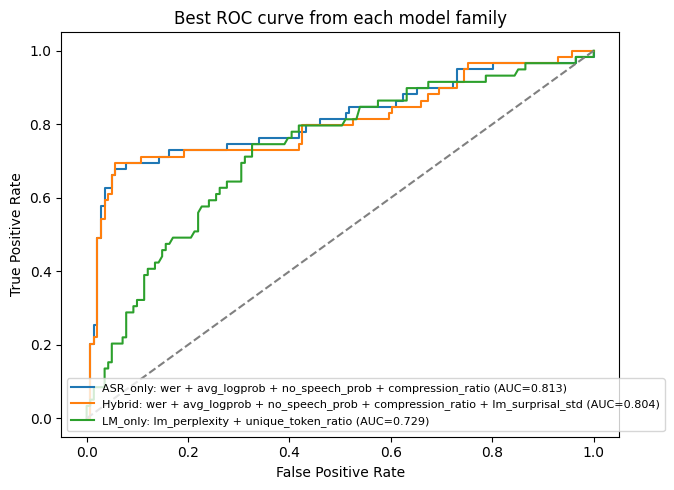

In [18]:
import matplotlib.pyplot as plt

top_group_names = best_by_group["ablation_name"].tolist()

plt.figure(figsize=(7, 5))
for name in top_group_names:
    run = stored_runs[name]
    auc = roc_auc_score(run["y_test"], run["y_score"])
    plt.plot(run["fpr"], run["tpr"], label=f"{run['group']}: {name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Best ROC curve from each model family")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 17. Plot DET curves for the strongest ASR, LM, and Hybrid models

This is especially important for your project, because DET curves expose the tradeoff between:
- false alarms
- missed hallucinations

The lower-left region is preferable.


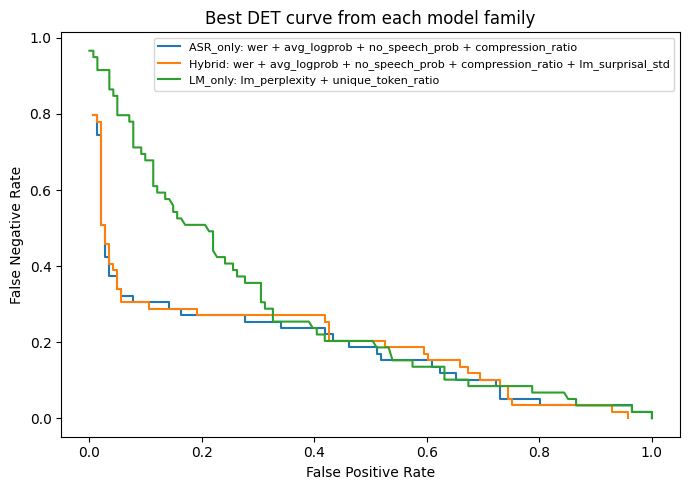

In [19]:
plt.figure(figsize=(7, 5))
for name in top_group_names:
    run = stored_runs[name]
    plt.plot(run["fpr_det"], run["fnr_det"], label=f"{run['group']}: {name}")

plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("Best DET curve from each model family")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 18. Detailed evaluation of the overall best model

Now we inspect the strongest model in more detail using:
- confusion matrix
- classification report
- ROC AUC
- Average Precision
- DET best operating point


In [20]:
best_y_test = best_run["y_test"]
best_y_pred = best_run["y_pred"]
best_y_score = best_run["y_score"]

cm = confusion_matrix(best_y_test, best_y_pred)

print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(best_y_test, best_y_pred, digits=4))
print("ROC AUC:", round(roc_auc_score(best_y_test, best_y_score), 4))
print("Average Precision:", round(average_precision_score(best_y_test, best_y_score), 4))
print("Best DET threshold:", round(best_row["det_best_threshold"], 4))
print("Best DET FPR:", round(best_row["det_best_fpr"], 4))
print("Best DET FNR:", round(best_row["det_best_fnr"], 4))


Confusion matrix:
[[131  10]
 [ 19  40]]

Classification report:
              precision    recall  f1-score   support

           0     0.8733    0.9291    0.9003       141
           1     0.8000    0.6780    0.7339        59

    accuracy                         0.8550       200
   macro avg     0.8367    0.8035    0.8171       200
weighted avg     0.8517    0.8550    0.8513       200

ROC AUC: 0.861
Average Precision: 0.8089
Best DET threshold: 0.4168
Best DET FPR: 0.1348
Best DET FNR: 0.2203


## 19. Inspect feature influence for the overall best model

If the selected model is logistic regression, we inspect coefficients directly.
If the selected model is tree-based, we fall back to feature importances.

This helps answer:
- which features push the model toward `hallucination`
- which features push it toward `no_hallucination`


In [21]:
feature_names = best_run.get("feature_names", best_features)
clf = best_run["clf"]

if hasattr(clf, "named_steps") and "poly" in clf.named_steps:
    poly = clf.named_steps["poly"]
    feature_names = poly.get_feature_names_out(feature_names).tolist()
    final_estimator = clf.named_steps["clf"]
else:
    final_estimator = clf.named_steps["clf"] if hasattr(clf, "named_steps") and "clf" in clf.named_steps else clf

if hasattr(final_estimator, "coef_"):
    influence_df = pd.DataFrame({
        "feature": feature_names,
        "influence": final_estimator.coef_[0],
    }).sort_values("influence", ascending=False).reset_index(drop=True)
elif hasattr(final_estimator, "feature_importances_"):
    influence_df = pd.DataFrame({
        "feature": feature_names,
        "influence": final_estimator.feature_importances_,
    }).sort_values("influence", ascending=False).reset_index(drop=True)
else:
    raise ValueError("The selected model does not expose coefficients or feature importances.")

influence_df


,feature,influence
0,avg_logprob asr_lm_conf_gap,1.089746
1,compression_ratio unique_token_ratio,1.061652
2,avg_logprob unique_token_ratio,1.028303
3,unique_token_ratio wer_x_lm_surprisal,0.634228
4,compression_ratio wer_x_lm_surprisal,0.560260
...,...,...
100,wer,-0.562223
101,no_speech_prob unique_token_ratio,-0.622137
102,lm_surprisal_std wer_x_lm_surprisal,-1.055687
103,no_speech_prob compression_ratio,-1.099106


## 20. Error analysis for the overall best model

We attach the model predictions back to the original rows so that mistakes can be inspected manually.

This is useful for checking whether the detector is:
- missing real hallucinations
- over-flagging difficult but valid transcripts
- confusing general ASR difficulty with true hallucination behavior


In [22]:
best_feature_rows = feature_df.loc[model_df.index].copy()
inspect_df = best_feature_rows.loc[best_run["X_test"].index].copy()
inspect_df["true"] = best_y_test.values
inspect_df["pred"] = best_y_pred
inspect_df["score"] = best_y_score

mistakes_df = inspect_df[inspect_df["true"] != inspect_df["pred"]].copy()

mistakes_path = OUTPUT_DIR / "hybrid_best_model_mistakes.csv"
mistakes_df.to_csv(mistakes_path, index=False)

print("Saved mistakes to:", mistakes_path.resolve())
print("Mistake count:", len(mistakes_df))

cols_to_show = [
    c for c in [
        "dataset",
        "source_file",
        "sample_id",
        "label_3class",
        "hallucination_binary",
        "pred_text",
        "wer",
        "avg_logprob",
        "no_speech_prob",
        "compression_ratio",
        "lm_avg_neg_logprob",
        "lm_perplexity",
        "lm_surprisal_std",
        "repetition_ratio",
        "unique_token_ratio",
        "true",
        "pred",
        "score",
    ]
    if c in mistakes_df.columns
]

mistakes_df[cols_to_show].head(20)


Saved mistakes to: /content/hybrid_detector_outputs/hybrid_best_model_mistakes.csv
Mistake count: 29


,dataset,source_file,sample_id,label_3class,hallucination_binary,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,true,pred,score
271,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0024__pink_10dB,Hallucination Error,hallucination,It is obviously unnecessary for us to point ou...,1.000000,-0.163974,0.018758,1.170213,4.971661,144.266328,3.596578,0.0,0.952381,1,0,0.379248
199,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0006__pink_10dB,Hallucination Error,hallucination,The strength that enables someone in a trance ...,1.000000,-0.140807,0.004258,1.235294,5.584624,266.300085,3.337213,0.0,0.960000,1,0,0.418679
151,commonvoice,commonvoice_annotation_completed .csv,ls_51,Hallucination Error,hallucination,"I rolled, clicked the maze at the sudden fury ...",1.166667,-0.315823,0.015230,1.028169,5.662527,287.875209,4.580839,0.0,0.823529,1,0,0.071261
626,primock_medical_noisy,primock_medical_noisy_labels.csv,mednoisy_day1_consultation07_patient,Non-Hallucination Error,no_hallucination,"Hello? Yes, yeah, I can. I can choose. I am no...",0.532571,-0.434455,0.535596,1.687145,2.481295,11.956740,2.113042,0.0,0.393064,0,1,0.920185
136,commonvoice,commonvoice_annotation_completed .csv,ls_36,Hallucination Error,hallucination,"I hope it doesn't work too hard, since shaggy.",0.888889,-0.259238,0.002833,0.851852,4.413594,82.565692,3.106000,0.0,1.000000,1,0,0.130788
588,primock_medical_noisy,primock_medical_noisy_labels.csv,mednoisy_day2_consultation01_patient,Non-Hallucination Error,no_hallucination,Can you find? Jack Smith 31st October 1990 I a...,0.452107,-0.582733,0.388355,1.185744,3.997201,54.445542,2.847068,0.0,0.641379,0,1,0.878548
109,commonvoice,commonvoice_annotation_completed .csv,ls_9,Hallucination Error,hallucination,"He was in the river, sliding along the borders...",1.100000,-0.325997,0.013356,0.955224,5.110592,165.768521,3.962399,0.0,0.923077,1,0,0.132957
575,primock_medical_noisy,primock_medical_noisy_labels.csv,mednoisy_day5_consultation05_doctor,Hallucination Error,hallucination,"Hi, I'm Dr Smith from Lavellum. Hi, can you se...",0.391892,-0.535756,0.243292,1.307470,3.864437,47.676428,2.696856,0.0,0.527027,1,0,0.471109
204,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0007__babble_10dB,Hallucination Error,hallucination,He thought it was the last burst of energy. He...,1.000000,-0.194944,0.018558,1.109756,4.004673,54.853884,3.105043,0.0,0.950000,1,0,0.422925
198,librispeech_fallback,librispeech_annotation_noisy.csv,ls_0006__white_10dB,Hallucination Error,hallucination,The strength that enables someone in a trance ...,1.000000,-0.168973,0.007766,1.235294,5.584624,266.300085,3.337213,0.0,0.960000,1,0,0.416752


## 21. Save prediction outputs

These saved files are useful for the final report and for sharing results with teammates:
- the full ablation table
- the best-model test predictions
- the best-model mistakes


In [23]:
predictions_df = inspect_df.copy()
predictions_path = OUTPUT_DIR / "hybrid_best_model_test_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved best-model predictions to:", predictions_path.resolve())
predictions_df.head()


Saved best-model predictions to: /content/hybrid_detector_outputs/hybrid_best_model_test_predictions.csv


,dataset,sample_id,reference_text,pred_text,wer,avg_logprob,no_speech_prob,compression_ratio,label_3class,hallucination_binary,...,y,lm_avg_neg_logprob,lm_perplexity,lm_surprisal_std,repetition_ratio,unique_token_ratio,token_count,true,pred,score
271,librispeech_fallback,ls_0024__pink_10dB,IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OU...,It is obviously unnecessary for us to point ou...,1.0,-0.163974,0.018758,1.170213,Hallucination Error,hallucination,...,1,4.971661,144.266328,3.596578,0.0,0.952381,21,1,0,0.379248
276,librispeech_fallback,ls_0025__babble_10dB,NOR IS MISTER QUILTER'S MANNER LESS INTERESTIN...,Nor is Mr. Quilter's matter less interesting t...,1.0,-0.330646,0.025334,1.016667,Non-Hallucination Error,no_hallucination,...,0,4.714398,111.541686,2.960218,0.0,0.866667,15,0,0,0.165182
11,adversarial,adv_4446-2271-0005,SHE SAVES HER HAND TOO SHE'S AT HER BEST IN TH...,She saves her hands too. She had her best in t...,1.0,-0.737511,0.126115,1.000000,Hallucination Error,hallucination,...,1,5.170770,176.050290,3.623422,0.0,0.866667,15,1,1,0.601365
526,librispeech,7176-88083-0006,IT MIGHT HAVE SEEMED THAT A TROUT OF THIS SIZE...,It might have seemed that a trout of this size...,1.0,-0.179689,0.001621,1.054795,No Error,no_hallucination,...,0,4.732662,113.597526,2.903868,0.0,0.937500,16,0,0,0.265397
159,commonvoice,ls_59,THE BUZZER'S WHIRR TRIGGERED HIS MUSCLES INTO ...,The buzzers were triggered his muscles into co...,1.0,-0.352458,0.006165,0.941176,Non-Hallucination Error,no_hallucination,...,0,7.151828,1276.436911,4.091929,0.0,1.000000,11,0,0,0.114494


## 22. Generate a report-friendly markdown summary

This cell writes a compact markdown file that summarizes:
- the best ASR-only result
- the best LM-only result
- the best Hybrid result
- the overall winner

This makes it easy to reuse the notebook output in the final report.


In [24]:
summary_lines = []
summary_lines.append("# Hybrid Hallucination Detection Summary")
summary_lines.append("")
summary_lines.append("## Data")
summary_lines.append(f"- Usable labeled rows: {len(valid_df)}")
summary_lines.append(f"- Rows with usable pred_text: {len(analysis_df)}")
summary_lines.append(f"- Rows used for modeling: {len(model_df)}")
summary_lines.append("")
summary_lines.append("## Best Result by Family")

for _, row in best_by_group.iterrows():
    summary_lines.append(f"### {row['group']}")
    summary_lines.append(f"- Name: {row['ablation_name']}")
    summary_lines.append(f"- Features: {row['features'].replace('|', ', ')}")
    summary_lines.append(f"- Accuracy: {row['accuracy']:.4f}")
    summary_lines.append(f"- Precision: {row['precision']:.4f}")
    summary_lines.append(f"- Recall: {row['recall']:.4f}")
    summary_lines.append(f"- F1: {row['f1']:.4f}")
    summary_lines.append(f"- ROC AUC: {row['roc_auc']:.4f}")
    summary_lines.append(f"- Average Precision: {row['avg_precision']:.4f}")
    summary_lines.append(f"- DET best FPR: {row['det_best_fpr']:.4f}")
    summary_lines.append(f"- DET best FNR: {row['det_best_fnr']:.4f}")
    summary_lines.append("")

summary_lines.append("## Overall Best Model")
summary_lines.append(f"- Group: {best_group}")
summary_lines.append(f"- Name: {best_name}")
summary_lines.append(f"- Features: {', '.join(best_features)}")
summary_lines.append(f"- Accuracy: {best_row['accuracy']:.4f}")
summary_lines.append(f"- Precision: {best_row['precision']:.4f}")
summary_lines.append(f"- Recall: {best_row['recall']:.4f}")
summary_lines.append(f"- F1: {best_row['f1']:.4f}")
summary_lines.append(f"- ROC AUC: {best_row['roc_auc']:.4f}")
summary_lines.append(f"- Average Precision: {best_row['avg_precision']:.4f}")
summary_lines.append(f"- DET best FPR: {best_row['det_best_fpr']:.4f}")
summary_lines.append(f"- DET best FNR: {best_row['det_best_fnr']:.4f}")
summary_lines.append("")

summary_lines.append("## Interpretation")
summary_lines.append(
    "- This notebook tests whether combining ASR-side and LM-side uncertainty creates a stronger hallucination detector than either family alone."
)
summary_lines.append(
    "- If the Hybrid family wins, it suggests the two signal sources are complementary."
)
summary_lines.append(
    "- If the ASR family still wins, that suggests Whisper-side uncertainty remains the most informative signal in the current data."
)

summary_text = "\n".join(summary_lines)
summary_path = OUTPUT_DIR / "hybrid_ablation_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print("Saved summary to:", summary_path.resolve())
print()
print(summary_text)


Saved summary to: /content/hybrid_detector_outputs/hybrid_ablation_summary.md

# Hybrid Hallucination Detection Summary

## Data
- Usable labeled rows: 665
- Rows with usable pred_text: 665
- Rows used for modeling: 665

## Best Result by Family
### ASR_only
- Name: wer + avg_logprob + no_speech_prob + compression_ratio
- Features: wer, avg_logprob, no_speech_prob, compression_ratio
- Accuracy: 0.8450
- Precision: 0.8889
- Recall: 0.5424
- F1: 0.6737
- ROC AUC: 0.8134
- Average Precision: 0.7234
- DET best FPR: 0.0567
- DET best FNR: 0.3220

### Hybrid
- Name: wer + avg_logprob + no_speech_prob + compression_ratio + lm_surprisal_std
- Features: wer, avg_logprob, no_speech_prob, compression_ratio, lm_surprisal_std
- Accuracy: 0.8300
- Precision: 0.8788
- Recall: 0.4915
- F1: 0.6304
- ROC AUC: 0.8044
- Average Precision: 0.7162
- DET best FPR: 0.0567
- DET best FNR: 0.3051

### LM_only
- Name: lm_perplexity + unique_token_ratio
- Features: lm_perplexity, unique_token_ratio
- Accuracy: 0.

## 23. Final interpretation guidance

How to use the result:

- If the hybrid model is best, you can report that combining ASR-side and transcript-side uncertainty improves hallucination detection.
- If ASR-only remains best, that is still an important result: it means the LM-side features add limited value beyond ASR uncertainty.
- If LM-only improves recall in some settings but not overall DET behavior, that is also useful to mention as a complementary signal.

This notebook is designed to support that comparison directly.
